In [1]:
import kagglehub

# Download latest version of OSF Lite dataset
path = kagglehub.dataset_download("kronomy/helmet-dataset-by-osf-lite")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite


# Motorcycle Helmet Detection — Step 4-Data + Step 4
## Chuẩn bị Dataset Phân lớp & Huấn luyện EfficientNetV2-S (6-node Multi-label)

---

### Vị trí trong Kiến trúc Hệ thống

```
LUỒNG A — TRAINING:
  Step 1a (YOLO dataset từ GT)  ──→ Step 2 (train YOLO detector)
  [Notebook này] Step 4-Data (classifier dataset từ OSF Lite)
               └──→ Step 4 (train EfficientNetV2 6-node)  ← NOTEBOOK NÀY
```

**Notebook này KHÔNG phụ thuộc vào output của Step 1, 2, hay 3.**
Đọc thẳng từ OSF Lite annotation (Ground Truth).

---

### Mục tiêu

**Phần 4-Data — Chuẩn bị Dataset:**
- Đọc annotation gốc OSF Lite → crop vùng xe máy theo từng track (Ground Truth bbox)
- Parse chuỗi label compound (`DHelmetP1NoHelmet`) sang vector 6-node multi-hot
- Xuất `multilabel_dataset.csv` + thư mục ảnh crop 224×224

**Phần 4 — Huấn luyện Mô hình:**
- Backbone: `EfficientNetV2-S` (pretrained ImageNet)
- Head: `nn.Linear(1280, 6)` — 6 outputs độc lập
- Loss: `BCEWithLogitsLoss` với `pos_weight` bù mất cân bằng dữ liệu
- Xuất `efficientnet_best.pth` + `training_history.json`

---

### Thiết kế Nhãn 6-node (đã chốt)

| Node | Tên | Nguồn pattern | Lý do thiết kế |
|------|-----|---------------|----------------|
| 0 | `Driver_WithHelmet` | `D.*Helmet` (không có NoHelmet sau D) | Tài xế đội mũ |
| 1 | `Driver_NoHelmet` | `DNoHelmet` | Tài xế không đội mũ |
| 2 | `Passenger1_WithHelmet` | `P1Helmet` | Hành khách 1 đội mũ |
| 3 | `Passenger1_NoHelmet` | `P1NoHelmet` | Hành khách 1 không đội |
| 4 | `Extra_Rider_WithHelmet` | `P2/P3/P0 Helmet` (gộp) | P3=0 mẫu, Child=46 → gộp chung |
| 5 | `Extra_Rider_NoHelmet` | `P2/P3/P0 NoHelmet` (gộp) | Tương tự |

**Lưu ý:** Node 4 & 5 gộp Extra_Rider vì P3_WithHelmet=0 mẫu, không đủ dữ liệu học riêng.


---
# PHẦN 4-DATA: CHUẨN BỊ DATASET PHÂN LỚP
---

## Section 1: Import Thư viện và Cấu hình Đường dẫn

In [2]:
# ============================================================================
# IMPORTS: Các thư viện cần thiết cho bước chuẩn bị dữ liệu
# ============================================================================

import os
import re
import json
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("✓ Thư viện đã được import thành công")

✓ Thư viện đã được import thành công


In [3]:
# ============================================================================
# CONFIGURATION: Định nghĩa đường dẫn và hằng số toàn cục
# ============================================================================

# --- Đường dẫn dataset gốc OSF Lite trên Kaggle (KHÔNG thay đổi) ---
ROOT_DIR       = '/kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite/helmet-dataset'
IMAGES_BASE    = os.path.join(ROOT_DIR, 'images')
ANNOTATION_DIR = os.path.join(ROOT_DIR, 'annotation', 'annotation')
SPLIT_CSV      = os.path.join(ROOT_DIR, 'data_split.csv')

# --- Đường dẫn output cho dataset phân lớp ---
OUTPUT_BASE     = '/kaggle/working'
CLASSIFIER_DIR  = os.path.join(OUTPUT_BASE, 'classifier_dataset')
IMAGES_OUT_DIR  = os.path.join(CLASSIFIER_DIR, 'images')   # flat directory chứa toàn bộ crop
CSV_OUT_PATH    = os.path.join(CLASSIFIER_DIR, 'multilabel_dataset.csv')
SUMMARY_PATH    = os.path.join(CLASSIFIER_DIR, 'classifier_dataset_summary.json')

# --- Thông số ảnh ---
IMAGE_HEIGHT = 1080
IMAGE_WIDTH  = 1920
CROP_SIZE    = 224          # Kích thước resize crop chuẩn input EfficientNetV2
PADDING_RATIO = 0.05        # Padding 5% quanh bounding box

# --- Số frames đại diện lấy từ mỗi track ---
# Lấy đều N_REPRESENTATIVE_FRAMES frames cách nhau để đại diện cho cả track
# → Mỗi track/xe sinh ra tối đa N_REPRESENTATIVE_FRAMES ảnh trong dataset
N_REPRESENTATIVE_FRAMES = 5

# --- Tạo thư mục output ---
os.makedirs(IMAGES_OUT_DIR, exist_ok=True)

print("✓ Cấu hình đường dẫn:")
print(f"  - Dataset gốc : {ROOT_DIR}")
print(f"  - Output crops: {IMAGES_OUT_DIR}")
print(f"  - Output CSV  : {CSV_OUT_PATH}")
print(f"  - Crop size   : {CROP_SIZE}×{CROP_SIZE}")
print(f"  - Frames/track: {N_REPRESENTATIVE_FRAMES}")

✓ Cấu hình đường dẫn:
  - Dataset gốc : /kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite/helmet-dataset
  - Output crops: /kaggle/working/classifier_dataset/images
  - Output CSV  : /kaggle/working/classifier_dataset/multilabel_dataset.csv
  - Crop size   : 224×224
  - Frames/track: 5


## Section 2: Khám phá Cấu trúc Dataset

In [4]:
# ============================================================================
# EXPLORE: Kiểm tra cấu trúc thư mục và thống kê sơ bộ dữ liệu đầu vào
# ============================================================================

print("=" * 80)
print("KHÁM PHÁ CẤU TRÚC DATASET OSF LITE")
print("=" * 80)

# --- Kiểm tra các thư mục parts ---
parts = sorted([d for d in os.listdir(IMAGES_BASE) if d.startswith('part_')])
print(f"\n✓ Tìm thấy {len(parts)} parts ảnh: {parts}")

# --- Kiểm tra annotation files ---
ann_files = [f for f in os.listdir(ANNOTATION_DIR) if f.endswith('.csv')]
print(f"✓ Tìm thấy {len(ann_files)} file annotation")
print(f"  Ví dụ: {ann_files[:3]}")

# --- Đọc data split ---
split_df = pd.read_csv(SPLIT_CSV)
# Chuẩn hóa cột Set: training/validation/test → train/val/test
split_map = {'training': 'train', 'validation': 'val', 'test': 'test'}
split_df['split'] = split_df['Set'].map(split_map)

print(f"\n✓ Phân chia dữ liệu:")
print(f"  - Tổng số clips: {len(split_df)}")
for s in ['train', 'val', 'test']:
    print(f"  - {s:5s}: {len(split_df[split_df['split'] == s])} clips")

# --- Kiểm tra 1 file annotation mẫu ---
sample_clip = ann_files[0].replace('.csv', '')
sample_ann  = pd.read_csv(os.path.join(ANNOTATION_DIR, ann_files[0]))
print(f"\n✓ Annotation mẫu: {ann_files[0]}")
print(f"  - Shape   : {sample_ann.shape}")
print(f"  - Columns : {list(sample_ann.columns)}")
print(f"  - Số tracks : {sample_ann['track_id'].nunique()}")
print(f"  - Unique labels: {sample_ann['label'].unique()[:5]}")
print()
print(sample_ann.head(5).to_string(index=False))

KHÁM PHÁ CẤU TRÚC DATASET OSF LITE

✓ Tìm thấy 2 parts ảnh: ['part_1', 'part_2']
✓ Tìm thấy 910 file annotation
  Ví dụ: ['Pakokku_urban_54.csv', 'Mandalay_2_133.csv', 'Mandalay_2_188.csv']

✓ Phân chia dữ liệu:
  - Tổng số clips: 910
  - train: 636 clips
  - val  : 92 clips
  - test : 182 clips

✓ Annotation mẫu: Pakokku_urban_54.csv
  - Shape   : (304, 7)
  - Columns : ['track_id', 'frame_id', 'x', 'y', 'w', 'h', 'label']
  - Số tracks : 8
  - Unique labels: ['DHelmetP1Helmet' 'DNoHelmetP1NoHelmet' 'DNoHelmet']

  track_id  frame_id    x   y  w   h           label
_9ij3ker8j         1 1581 328 55 102 DHelmetP1Helmet
_9ij3ker8j         2 1570 329 56 104 DHelmetP1Helmet
_9ij3ker8j         3 1559 331 57 104 DHelmetP1Helmet
_9ij3ker8j         4 1548 332 58 105 DHelmetP1Helmet
_9ij3ker8j         5 1537 333 59 107 DHelmetP1Helmet


## Section 3: Định nghĩa Hàm Phân tích Nhãn 6-node

Đây là hàm cốt lõi — **phải dùng nhất quán** ở cả bước chuẩn bị data (Section này)
lẫn bước Evaluation (Step 6), để đảm bảo Predicted và Ground Truth dùng cùng 1 schema.

In [5]:
# ============================================================================
# LABEL PARSING: Chuyển đổi chuỗi label compound sang vector 6-node multi-hot
# ============================================================================
# Thiết kế nhãn 6-node (đã chốt):
#   Node 0: Driver_WithHelmet     → D có Helmet, không có NoHelmet ngay sau
#   Node 1: Driver_NoHelmet       → DNoHelmet
#   Node 2: Passenger1_WithHelmet → P1Helmet
#   Node 3: Passenger1_NoHelmet   → P1NoHelmet
#   Node 4: Extra_Rider_WithHelmet→ P2/P3/P0(Child) Helmet — gộp chung do ít mẫu
#   Node 5: Extra_Rider_NoHelmet  → P2/P3/P0(Child) NoHelmet — gộp chung
# ============================================================================

# Tên hiển thị cho 6 nodes (dùng làm tên cột trong CSV)
NODE_NAMES = ['D_H', 'D_NH', 'P1_H', 'P1_NH', 'Extra_H', 'Extra_NH']
NODE_LABELS_FULL = [
    'Driver_WithHelmet',
    'Driver_NoHelmet',
    'Passenger1_WithHelmet',
    'Passenger1_NoHelmet',
    'Extra_Rider_WithHelmet',
    'Extra_Rider_NoHelmet',
]


def label_to_multihot(label_str: str) -> list:
    """
    Chuyển đổi chuỗi label compound từ OSF Lite sang vector 6-node multi-hot.

    Ví dụ:
        'DHelmetP1NoHelmet'  → [1, 0, 0, 1, 0, 0]
        'DNoHelmetP1Helmet'  → [0, 1, 1, 0, 0, 0]
        'DHelmetP2NoHelmet'  → [1, 0, 0, 0, 0, 1]
        'DNoHelmet'          → [0, 1, 0, 0, 0, 0]

    Args:
        label_str: Chuỗi nhãn compound từ cột 'label' trong annotation CSV.

    Returns:
        list[int]: Vector 6 phần tử, mỗi phần tử 0 hoặc 1.
        Trả về [0,0,0,0,0,0] nếu label_str rỗng hoặc không khớp (sẽ bị lọc sau).
    """
    label_str = str(label_str).strip()
    vec = [0, 0, 0, 0, 0, 0]

    # Node 0 — Driver_WithHelmet:
    # Có 'D...Helmet' nhưng KHÔNG phải 'DNoHelmet'
    if re.search(r'D(?!No)Helmet', label_str):
        vec[0] = 1

    # Node 1 — Driver_NoHelmet:
    if 'DNoHelmet' in label_str:
        vec[1] = 1

    # Node 2 — Passenger1_WithHelmet:
    # P1Helmet nhưng không phải P1NoHelmet
    if re.search(r'P1(?!No)Helmet', label_str):
        vec[2] = 1

    # Node 3 — Passenger1_NoHelmet:
    if 'P1NoHelmet' in label_str:
        vec[3] = 1

    # Node 4 — Extra_Rider_WithHelmet:
    # Gộp: P2Helmet | P3Helmet | P0Helmet (Child)
    if re.search(r'P[023](?!No)Helmet', label_str):
        vec[4] = 1

    # Node 5 — Extra_Rider_NoHelmet:
    # Gộp: P2NoHelmet | P3NoHelmet | P0NoHelmet (Child)
    if re.search(r'P[023]NoHelmet', label_str):
        vec[5] = 1

    return vec


# --- Unit test nhanh để đảm bảo hàm hoạt động đúng ---
test_cases = [
    ('DHelmetP1NoHelmet',  [1, 0, 0, 1, 0, 0]),
    ('DNoHelmetP1Helmet',  [0, 1, 1, 0, 0, 0]),
    ('DHelmetP2NoHelmet',  [1, 0, 0, 0, 0, 1]),
    ('DNoHelmet',          [0, 1, 0, 0, 0, 0]),
    ('DHelmetP1HelmetP0NoHelmet', [1, 0, 1, 0, 0, 1]),
    ('DHelmetP1Helmet',    [1, 0, 1, 0, 0, 0]),
]

print("✓ Unit test hàm label_to_multihot():")
all_pass = True
for label, expected in test_cases:
    result = label_to_multihot(label)
    status = "PASS" if result == expected else "FAIL"
    if status == "FAIL":
        all_pass = False
    print(f"  [{status}] '{label}'")
    print(f"         Expected: {expected}")
    print(f"         Got     : {result}")

print()
if all_pass:
    print("✓ Tất cả test cases PASS — hàm label_to_multihot() sẵn sàng sử dụng")
else:
    print("✗ Có test case FAIL — kiểm tra lại regex!")

✓ Unit test hàm label_to_multihot():
  [PASS] 'DHelmetP1NoHelmet'
         Expected: [1, 0, 0, 1, 0, 0]
         Got     : [1, 0, 0, 1, 0, 0]
  [PASS] 'DNoHelmetP1Helmet'
         Expected: [0, 1, 1, 0, 0, 0]
         Got     : [0, 1, 1, 0, 0, 0]
  [PASS] 'DHelmetP2NoHelmet'
         Expected: [1, 0, 0, 0, 0, 1]
         Got     : [1, 0, 0, 0, 0, 1]
  [PASS] 'DNoHelmet'
         Expected: [0, 1, 0, 0, 0, 0]
         Got     : [0, 1, 0, 0, 0, 0]
  [PASS] 'DHelmetP1HelmetP0NoHelmet'
         Expected: [1, 0, 1, 0, 0, 1]
         Got     : [1, 0, 1, 0, 0, 1]
  [PASS] 'DHelmetP1Helmet'
         Expected: [1, 0, 1, 0, 0, 0]
         Got     : [1, 0, 1, 0, 0, 0]

✓ Tất cả test cases PASS — hàm label_to_multihot() sẵn sàng sử dụng


## Section 4: Định nghĩa Hàm Tiện ích — Crop, Resize, Frame Sampling

In [6]:
# ============================================================================
# UTILITY FUNCTIONS: Các hàm tiện ích để crop ảnh và chọn frame đại diện
# ============================================================================


def find_clip_image_dir(clip_name: str, parts: list, images_base: str):
    """
    Tìm thư mục ảnh của clip trong các parts.

    Args:
        clip_name  : Tên clip (VD: 'Bago_highway_1')
        parts      : Danh sách tên parts (VD: ['part_1', 'part_2'])
        images_base: Đường dẫn thư mục images gốc

    Returns:
        str | None: Đường dẫn thư mục ảnh nếu tìm thấy, ngược lại None.
    """
    for part in parts:
        candidate = os.path.join(images_base, part, clip_name)
        if os.path.isdir(candidate):
            return candidate
    return None


def select_representative_frames(frame_ids: list, n: int = N_REPRESENTATIVE_FRAMES) -> list:
    """
    Chọn N frame đại diện phân bổ đều trong dải frame của 1 track.

    Cách chọn: lấy đều từ đầu đến cuối dải frame (linspace).
    Điều này đảm bảo mẫu phân bổ tốt hơn so với chỉ lấy frame giữa.

    Args:
        frame_ids: Danh sách frame ID trong track (có thể không liên tục)
        n        : Số frame muốn chọn

    Returns:
        list[int]: Danh sách frame ID đã chọn.
    """
    sorted_ids = sorted(frame_ids)
    if len(sorted_ids) <= n:
        return sorted_ids
    # Lấy đều n index trong khoảng [0, len-1]
    indices = np.linspace(0, len(sorted_ids) - 1, n, dtype=int)
    return [sorted_ids[i] for i in indices]


def crop_and_resize(img: np.ndarray, x: int, y: int, w: int, h: int,
                    padding: float = PADDING_RATIO,
                    output_size: int = CROP_SIZE) -> np.ndarray | None:
    """
    Crop vùng xe máy từ frame gốc với padding, sau đó resize về output_size×output_size.

    Args:
        img        : Ảnh gốc (BGR numpy array)
        x, y, w, h : Bounding box gốc (top-left + width/height, pixel tuyệt đối)
        padding    : Tỷ lệ padding thêm quanh bbox (mặc định 5%)
        output_size: Kích thước ảnh crop sau resize (mặc định 224)

    Returns:
        np.ndarray | None: Ảnh đã crop & resize, hoặc None nếu bbox không hợp lệ.
    """
    img_h, img_w = img.shape[:2]

    # Tính padding pixels
    pad_x = int(w * padding)
    pad_y = int(h * padding)

    # Mở rộng bbox, clamp về biên ảnh
    x1 = max(0,     x - pad_x)
    y1 = max(0,     y - pad_y)
    x2 = min(img_w, x + w + pad_x)
    y2 = min(img_h, y + h + pad_y)

    # Kiểm tra bbox hợp lệ (diện tích > 0)
    if x2 <= x1 or y2 <= y1:
        return None

    crop = img[y1:y2, x1:x2]

    # Resize về output_size×output_size (chuẩn input EfficientNetV2)
    resized = cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_LINEAR)
    return resized


print("✓ Các hàm tiện ích đã được định nghĩa:")
print("  - find_clip_image_dir()")
print("  - select_representative_frames()")
print("  - crop_and_resize()")

✓ Các hàm tiện ích đã được định nghĩa:
  - find_clip_image_dir()
  - select_representative_frames()
  - crop_and_resize()


## Section 5: Build Dataset — Crop + Label + Export CSV

Đây là cell xử lý chính. Với mỗi clip → mỗi track → chọn N frame đại diện:
1. Crop vùng xe máy (padding 5%)
2. Resize về 224×224
3. Parse label sang vector 6-node
4. Ghi vào CSV và lưu ảnh

**Idempotent:** Nếu ảnh đã tồn tại, bỏ qua (không ghi đè).

In [7]:
# ============================================================================
# BUILD DATASET: Xử lý toàn bộ 910 clips → xuất ảnh crop + multilabel CSV
# ============================================================================
# Quy trình:
#   Với mỗi clip trong split_df:
#     1. Load annotation CSV → group by track_id
#     2. Với mỗi track: xác định nhãn đa số (mode) của cột 'label'
#     3. Chọn N_REPRESENTATIVE_FRAMES frames đại diện
#     4. Với mỗi frame: crop bbox → resize → lưu ảnh
#     5. Ghi record vào rows_list (clip, track, file_name, split, 6 nodes)
# ============================================================================

print("=" * 80)
print("BUILD CLASSIFIER DATASET — Crop + Label + Export")
print("=" * 80)

rows_list    = []   # Danh sách record → sẽ xuất thành DataFrame
total_crops  = 0
skipped_clips = 0
error_count  = 0
zero_vec_count = 0  # Đếm record có vector [0,0,0,0,0,0] → sẽ bị lọc

pbar = tqdm(split_df.iterrows(), total=len(split_df),
            desc="Processing clips", unit="clip")

for _, row in pbar:
    clip_name = row['video_id']
    split     = row['split']      # 'train' | 'val' | 'test'

    # --- Kiểm tra file annotation ---
    ann_path = os.path.join(ANNOTATION_DIR, f"{clip_name}.csv")
    if not os.path.exists(ann_path):
        skipped_clips += 1
        continue

    # --- Tìm thư mục ảnh của clip ---
    clip_img_dir = find_clip_image_dir(clip_name, parts, IMAGES_BASE)
    if clip_img_dir is None:
        skipped_clips += 1
        continue

    try:
        ann_df = pd.read_csv(ann_path)
    except Exception as e:
        # Bắt lỗi đọc file → log cảnh báo rồi tiếp tục, không dừng pipeline
        error_count += 1
        pbar.write(f"  [WARN] Không đọc được {ann_path}: {e}")
        continue

    # --- Group by track_id → xử lý từng xe/track ---
    for track_id, track_df in ann_df.groupby('track_id'):

        # Lấy nhãn đại diện cho track = mode (nhãn xuất hiện nhiều nhất)
        # Nếu label thay đổi theo frame (hiếm), dùng mode để ổn định
        label_mode = track_df['label'].mode().iloc[0]
        vec = label_to_multihot(label_mode)

        # Lọc bỏ vector toàn 0 → xe không có người (annotation lỗi)
        if sum(vec) == 0:
            zero_vec_count += 1
            continue

        # Chọn N frame đại diện trong track
        all_frame_ids = track_df['frame_id'].tolist()
        chosen_frames = select_representative_frames(all_frame_ids, N_REPRESENTATIVE_FRAMES)

        for frame_id in chosen_frames:
            frame_rows = track_df[track_df['frame_id'] == frame_id]
            if frame_rows.empty:
                continue

            # Lấy dòng đầu tiên (mỗi track chỉ có 1 bbox/frame)
            fr = frame_rows.iloc[0]
            x, y, w, h = int(fr['x']), int(fr['y']), int(fr['w']), int(fr['h'])

            # Tên file ảnh output: {clip}_{track}_{frame}.jpg
            # Dùng hash-safe: track_id có thể chứa ký tự đặc biệt → replace
            safe_track = str(track_id).replace('/', '_').replace(' ', '_')
            out_filename = f"{clip_name}__{safe_track}__f{frame_id}.jpg"
            out_path = os.path.join(IMAGES_OUT_DIR, out_filename)

            # Idempotent: bỏ qua nếu ảnh đã được tạo trước đó
            if not os.path.exists(out_path):
                img_path = os.path.join(clip_img_dir, f"{frame_id}.jpg")
                if not os.path.exists(img_path):
                    continue

                try:
                    img = cv2.imread(img_path)
                    if img is None:
                        error_count += 1
                        continue

                    crop = crop_and_resize(img, x, y, w, h)
                    if crop is None:
                        error_count += 1
                        continue

                    cv2.imwrite(out_path, crop)

                    # Giải phóng RAM chủ động sau mỗi ảnh lớn
                    del img, crop

                except Exception as e:
                    error_count += 1
                    pbar.write(f"  [WARN] {clip_name} frame {frame_id}: {e}")
                    continue

            # Ghi record vào danh sách
            rows_list.append({
                'clip_name' : clip_name,
                'track_id'  : str(track_id),
                'frame_id'  : frame_id,
                'file_name' : out_filename,
                'split'     : split,
                'label_raw' : label_mode,
                # 6 nodes
                'D_H'      : vec[0],
                'D_NH'     : vec[1],
                'P1_H'     : vec[2],
                'P1_NH'    : vec[3],
                'Extra_H'  : vec[4],
                'Extra_NH' : vec[5],
            })
            total_crops += 1

    pbar.set_postfix(crops=total_crops, errors=error_count)

print(f"\n✓ Xử lý hoàn tất!")
print(f"  - Tổng crops/records: {total_crops}")
print(f"  - Clips bị bỏ qua   : {skipped_clips}")
print(f"  - Lỗi bỏ qua        : {error_count}")
print(f"  - Vector rỗng (lọc) : {zero_vec_count}")

BUILD CLASSIFIER DATASET — Crop + Label + Export


Processing clips: 100%|██████████| 910/910 [03:58<00:00,  3.82clip/s, crops=8789, errors=0] 


✓ Xử lý hoàn tất!
  - Tổng crops/records: 8789
  - Clips bị bỏ qua   : 623
  - Lỗi bỏ qua        : 0
  - Vector rỗng (lọc) : 0


In [8]:
# ============================================================================
# EXPORT CSV: Lưu multilabel_dataset.csv — mapping ảnh → nhãn 6-node
# ============================================================================

dataset_df = pd.DataFrame(rows_list)

# Loại bỏ duplicate file_name (phòng trường hợp chạy lại)
dataset_df = dataset_df.drop_duplicates(subset='file_name').reset_index(drop=True)

# Lưu CSV
dataset_df.to_csv(CSV_OUT_PATH, index=False)

print(f"✓ Dataset CSV đã được lưu: {CSV_OUT_PATH}")
print(f"  - Tổng records : {len(dataset_df)}")
print()
print("  Phân bổ theo split:")
print(dataset_df['split'].value_counts().to_string())
print()
print("  5 dòng đầu:")
print(dataset_df.head().to_string(index=False))

✓ Dataset CSV đã được lưu: /kaggle/working/classifier_dataset/multilabel_dataset.csv
  - Tổng records : 8789

  Phân bổ theo split:
split
train    6059
test     1687
val      1043

  5 dòng đầu:
     clip_name   track_id  frame_id                           file_name split label_raw  D_H  D_NH  P1_H  P1_NH  Extra_H  Extra_NH
Bago_highway_1 _7kioiwczg        17 Bago_highway_1___7kioiwczg__f17.jpg   val DNoHelmet    0     1     0      0        0         0
Bago_highway_1 _7kioiwczg        36 Bago_highway_1___7kioiwczg__f36.jpg   val DNoHelmet    0     1     0      0        0         0
Bago_highway_1 _7kioiwczg        55 Bago_highway_1___7kioiwczg__f55.jpg   val DNoHelmet    0     1     0      0        0         0
Bago_highway_1 _7kioiwczg        74 Bago_highway_1___7kioiwczg__f74.jpg   val DNoHelmet    0     1     0      0        0         0
Bago_highway_1 _7kioiwczg        93 Bago_highway_1___7kioiwczg__f93.jpg   val DNoHelmet    0     1     0      0        0         0


## Section 6: Kiểm tra và Thống kê Dataset

In [9]:
# ============================================================================
# VERIFY & STATS: Kiểm tra chất lượng dataset và in thống kê phân phối nhãn
# ============================================================================

print("=" * 80)
print("THỐNG KÊ VÀ KIỂM TRA DATASET")
print("=" * 80)

label_cols = NODE_NAMES  # ['D_H', 'D_NH', 'P1_H', 'P1_NH', 'Extra_H', 'Extra_NH']

# --- Kiểm tra 1: Không có vector toàn 0 ---
zero_mask = (dataset_df[label_cols].sum(axis=1) == 0)
if zero_mask.any():
    print(f"✗ CẢNH BÁO: Tìm thấy {zero_mask.sum()} records với vector nhãn toàn 0!")
    print(dataset_df[zero_mask][['file_name', 'label_raw']].head())
else:
    print("✓ Kiểm tra 1 PASS: Không có record nào có vector nhãn toàn 0")

# --- Kiểm tra 2: Không có file ảnh nào bị thiếu ---
missing_files = []
for fname in dataset_df['file_name']:
    if not os.path.exists(os.path.join(IMAGES_OUT_DIR, fname)):
        missing_files.append(fname)

if missing_files:
    print(f"✗ CẢNH BÁO: {len(missing_files)} file ảnh bị thiếu!")
    print(missing_files[:5])
else:
    print("✓ Kiểm tra 2 PASS: Tất cả file ảnh tồn tại")

# --- Thống kê phân phối nhãn theo từng node ---
print()
print("  Phân phối nhãn theo từng node (toàn bộ dataset):")
print(f"  {'Node':<25} {'Positive (=1)':>15} {'Negative (=0)':>15} {'Tỷ lệ Pos':>12}")
print("  " + "-" * 70)
for col, full_name in zip(label_cols, NODE_LABELS_FULL):
    pos = int(dataset_df[col].sum())
    neg = len(dataset_df) - pos
    ratio = pos / len(dataset_df) * 100
    print(f"  {full_name:<25} {pos:>15,} {neg:>15,} {ratio:>11.1f}%")

# --- Thống kê theo split ---
print()
print("  Phân phối nhãn theo split:")
for split_name in ['train', 'val', 'test']:
    sub = dataset_df[dataset_df['split'] == split_name]
    print(f"\n  [{split_name.upper()}] — {len(sub)} records")
    print(f"  {'Node':<25} {'Pos':>8} {'Neg':>8}")
    for col, full_name in zip(label_cols, NODE_LABELS_FULL):
        pos = int(sub[col].sum())
        neg = len(sub) - pos
        print(f"  {full_name:<25} {pos:>8,} {neg:>8,}")

THỐNG KÊ VÀ KIỂM TRA DATASET
✓ Kiểm tra 1 PASS: Không có record nào có vector nhãn toàn 0
✓ Kiểm tra 2 PASS: Tất cả file ảnh tồn tại

  Phân phối nhãn theo từng node (toàn bộ dataset):
  Node                        Positive (=1)   Negative (=0)    Tỷ lệ Pos
  ----------------------------------------------------------------------
  Driver_WithHelmet                   6,906           1,883        78.6%
  Driver_NoHelmet                     1,883           6,906        21.4%
  Passenger1_WithHelmet               2,023           6,766        23.0%
  Passenger1_NoHelmet                 1,327           7,462        15.1%
  Extra_Rider_WithHelmet                128           8,661         1.5%
  Extra_Rider_NoHelmet                  339           8,450         3.9%

  Phân phối nhãn theo split:

  [TRAIN] — 6059 records
  Node                           Pos      Neg
  Driver_WithHelmet            4,740    1,319
  Driver_NoHelmet              1,319    4,740
  Passenger1_WithHelmet        1,404 

## Section 7: Lưu Summary JSON — Kết thúc Phần 4-Data

In [10]:
# ============================================================================
# SAVE SUMMARY: Lưu classifier_dataset_summary.json để Step 4 verify input
# ============================================================================

# Tính pos_weight gợi ý cho Step 4 (tỷ lệ Neg/Pos cho BCEWithLogitsLoss)
# pos_weight = neg_count / pos_count → nhấn mạnh class thiểu số
train_sub = dataset_df[dataset_df['split'] == 'train']
suggested_pos_weights = []
for col in label_cols:
    pos = max(1, int(train_sub[col].sum()))  # tránh chia 0
    neg = len(train_sub) - pos
    pw  = round(neg / pos, 2)
    suggested_pos_weights.append(pw)

summary = {
    "step"           : "4-Data",
    "description"    : "Classifier dataset chuẩn bị cho EfficientNetV2 6-node multi-label",
    "total_records"  : int(len(dataset_df)),
    "splits"         : {
        s: int(len(dataset_df[dataset_df['split'] == s]))
        for s in ['train', 'val', 'test']
    },
    "crop_size"      : CROP_SIZE,
    "padding_ratio"  : PADDING_RATIO,
    "frames_per_track": N_REPRESENTATIVE_FRAMES,
    "nodes"          : NODE_NAMES,
    "node_full_names": NODE_LABELS_FULL,
    "node_distribution": {
        col: {
            "positive": int(dataset_df[col].sum()),
            "negative": int(len(dataset_df) - dataset_df[col].sum()),
        }
        for col in label_cols
    },
    "suggested_pos_weights": suggested_pos_weights,
    "paths": {
        "images_dir" : IMAGES_OUT_DIR,
        "csv_path"   : CSV_OUT_PATH,
    }
}

with open(SUMMARY_PATH, 'w') as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print("=" * 80)
print("✓ STEP 4-DATA HOÀN TẤT")
print("=" * 80)
print(f"  Tổng records      : {summary['total_records']:,}")
print(f"  Train / Val / Test: {summary['splits']['train']} / {summary['splits']['val']} / {summary['splits']['test']}")
print(f"  Crop size         : {CROP_SIZE}×{CROP_SIZE} px")
print(f"  Summary JSON      : {SUMMARY_PATH}")
print()
print(f"  Gợi ý pos_weight cho BCEWithLogitsLoss (train split):")
for name, pw in zip(NODE_LABELS_FULL, suggested_pos_weights):
    print(f"    {name:<28}: {pw}")
print()
print("  Bước tiếp theo: Phần 4 — Huấn luyện EfficientNetV2-S")

✓ STEP 4-DATA HOÀN TẤT
  Tổng records      : 8,789
  Train / Val / Test: 6059 / 1043 / 1687
  Crop size         : 224×224 px
  Summary JSON      : /kaggle/working/classifier_dataset/classifier_dataset_summary.json

  Gợi ý pos_weight cho BCEWithLogitsLoss (train split):
    Driver_WithHelmet           : 0.28
    Driver_NoHelmet             : 3.59
    Passenger1_WithHelmet       : 3.32
    Passenger1_NoHelmet         : 5.22
    Extra_Rider_WithHelmet      : 49.49
    Extra_Rider_NoHelmet        : 23.93

  Bước tiếp theo: Phần 4 — Huấn luyện EfficientNetV2-S


---
# PHẦN 4: HUẤN LUYỆN MÔ HÌNH EFFICIENTNETV2-S (6-NODE MULTI-LABEL)
---

## Section 8: Import PyTorch và Cấu hình Huấn luyện

**Kiến trúc mô hình:**
- **Backbone:** `EfficientNetV2-S` pretrained ImageNet (torchvision)
- **Head:** `nn.Linear(1280, 6)` — 6 outputs độc lập
- **Activation:** Sigmoid (multi-label → mỗi node độc lập, không dùng Softmax)
- **Loss:** `BCEWithLogitsLoss` với `pos_weight` bù mất cân bằng

**Lưu ý augmentation:**
- ✅ Cho phép: `ColorJitter`, `RandomRotation(±10°)`, `RandomResizedCrop`
- ❌ **CẤM:** `RandomHorizontalFlip` — lật ngang phá vỡ spatial signal vị trí Driver (trái/phải xe)

In [11]:
# ============================================================================
# IMPORTS: Thư viện PyTorch và torchvision cho huấn luyện
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# Kiểm tra GPU (Kaggle T4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Thiết bị tính toán: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Seed cố định để tái tạo kết quả
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("✓ Seed đã được cố định:", SEED)

✓ Thiết bị tính toán: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
✓ Seed đã được cố định: 42


In [12]:
# ============================================================================
# HYPERPARAMETERS: Các tham số huấn luyện tối ưu cho Kaggle T4
# ============================================================================

# --- Đường dẫn dataset (đầu ra từ Phần 4-Data) ---
CSV_PATH   = '/kaggle/working/classifier_dataset/multilabel_dataset.csv'
IMG_DIR    = '/kaggle/working/classifier_dataset/images'
OUTPUT_DIR = '/kaggle/working'

# --- Hyperparameters ---
EPOCHS        = 30
BATCH_SIZE    = 32
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
NUM_NODES     = 6
INPUT_SIZE    = 224
NUM_WORKERS   = 2    # Số workers cho DataLoader (phù hợp Kaggle)
THRESHOLD     = 0.5  # Ngưỡng quyết định sigmoid → binary

# Early stopping patience (dừng sớm nếu Val macro-F1 không cải thiện)
PATIENCE = 5

# --- Pos_weight cho BCEWithLogitsLoss ---
# Tỷ lệ nghịch với tần suất dương trong train split
# (tự động đọc từ summary JSON nếu có, fallback về giá trị mặc định)
try:
    with open('/kaggle/working/classifier_dataset/classifier_dataset_summary.json') as f:
        ds_summary = json.load(f)
    POS_WEIGHTS = ds_summary['suggested_pos_weights']
    print("✓ Đọc pos_weight từ summary JSON:")
except Exception:
    # Fallback: giá trị thủ công dựa trên phân phối OSF Lite
    POS_WEIGHTS = [1.0, 3.0, 3.0, 5.0, 10.0, 8.0]
    print("[INFO] Dùng pos_weight mặc định (summary JSON không tìm thấy):")

for name, pw in zip(NODE_LABELS_FULL, POS_WEIGHTS):
    print(f"  {name:<28}: {pw}")

print()
print("✓ Hyperparameters:")
print(f"  epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}, weight_decay={WEIGHT_DECAY}")
print(f"  threshold={THRESHOLD}, patience={PATIENCE}")

✓ Đọc pos_weight từ summary JSON:
  Driver_WithHelmet           : 0.28
  Driver_NoHelmet             : 3.59
  Passenger1_WithHelmet       : 3.32
  Passenger1_NoHelmet         : 5.22
  Extra_Rider_WithHelmet      : 49.49
  Extra_Rider_NoHelmet        : 23.93

✓ Hyperparameters:
  epochs=30, batch=32, lr=0.0003, weight_decay=0.0001
  threshold=0.5, patience=5


## Section 9: Custom Dataset — HelmetMultiLabelDataset

In [13]:
# ============================================================================
# DATASET CLASS: HelmetMultiLabelDataset
# Đọc ảnh crop từ thư mục flat và nhãn từ multilabel_dataset.csv
# ============================================================================

class HelmetMultiLabelDataset(Dataset):
    """
    PyTorch Dataset cho bài toán phân loại đội mũ bảo hiểm 6-node multi-label.

    Đọc từ multilabel_dataset.csv với cột:
        file_name, split, D_H, D_NH, P1_H, P1_NH, Extra_H, Extra_NH

    Args:
        csv_path  : Đường dẫn file multilabel_dataset.csv
        img_dir   : Thư mục chứa ảnh crop (flat directory)
        split     : 'train' | 'val' | 'test'
        transform : torchvision transforms (nếu None → chỉ resize + normalize)
    """

    LABEL_COLS = ['D_H', 'D_NH', 'P1_H', 'P1_NH', 'Extra_H', 'Extra_NH']

    def __init__(self, csv_path: str, img_dir: str, split: str, transform=None):
        df = pd.read_csv(csv_path)
        self.data      = df[df['split'] == split].reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

        print(f"  Dataset [{split}]: {len(self.data)} samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row      = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['file_name'])

        # Đọc ảnh bằng PIL (torchvision transforms yêu cầu PIL Image)
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            # Trả về ảnh đen nếu không đọc được (tránh crash DataLoader)
            img = Image.fromarray(np.zeros((INPUT_SIZE, INPUT_SIZE, 3), dtype=np.uint8))

        if self.transform:
            img = self.transform(img)

        # Vector nhãn 6-node dạng float32 cho BCEWithLogitsLoss
        label = torch.tensor(
            row[self.LABEL_COLS].values.astype(float),
            dtype=torch.float32
        )
        return img, label


# ============================================================================
# TRANSFORMS: Augmentation cho train, chỉ normalize cho val/test
# ============================================================================
# Chuẩn hóa ImageNet (chuẩn pretrained EfficientNetV2)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # RandomResizedCrop: crop ngẫu nhiên 85-100% rồi resize về 224
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.85, 1.0)),
    # ColorJitter: thay đổi màu sắc nhẹ (điều kiện ánh sáng thực tế)
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    # RandomRotation: xoay nhẹ ±10° (xe máy đôi khi hơi nghiêng)
    transforms.RandomRotation(degrees=10),
    # ❌ KHÔNG dùng RandomHorizontalFlip — phá vỡ spatial signal trái/phải
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# ============================================================================
# DATALOADERS: Khởi tạo DataLoader cho train / val / test
# ============================================================================

print("✓ Khởi tạo Datasets:")
train_dataset = HelmetMultiLabelDataset(CSV_PATH, IMG_DIR, 'train', train_transform)
val_dataset   = HelmetMultiLabelDataset(CSV_PATH, IMG_DIR, 'val',   val_transform)
test_dataset  = HelmetMultiLabelDataset(CSV_PATH, IMG_DIR, 'test',  val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✓ DataLoader sẵn sàng:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print(f"  Test batches : {len(test_loader)}")

✓ Khởi tạo Datasets:
  Dataset [train]: 6059 samples
  Dataset [val]: 1043 samples
  Dataset [test]: 1687 samples

✓ DataLoader sẵn sàng:
  Train batches: 190
  Val batches  : 33
  Test batches : 53


## Section 10: Xây dựng Mô hình EfficientNetV2-S với 6-node Head

In [14]:
# ============================================================================
# MODEL DEFINITION: EfficientNetV2-S với 6-node Multi-label Classification Head
# ============================================================================


def build_efficientnetv2_s(num_nodes: int = 6, pretrained: bool = True) -> nn.Module:
    """
    Xây dựng mô hình EfficientNetV2-S với custom classification head.

    Kiến trúc:
        - Backbone: EfficientNetV2-S pretrained ImageNet (torchvision)
        - Classifier head gốc được thay thế bằng:
            Dropout(0.3) → Linear(1280, num_nodes)
        - Không có Sigmoid ở output (dùng BCEWithLogitsLoss kết hợp sigmoid nội bộ)

    Args:
        num_nodes : Số output nodes (mặc định 6)
        pretrained: Dùng pretrained ImageNet weights hay không

    Returns:
        nn.Module: Mô hình đã sẵn sàng huấn luyện
    """
    weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.efficientnet_v2_s(weights=weights)

    # Lấy số features của classifier gốc (thường là 1280 với EfficientNetV2-S)
    in_features = model.classifier[1].in_features

    # Thay thế classifier head bằng 6-node multi-label head
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_nodes),
        # Không có Sigmoid ở đây — BCEWithLogitsLoss xử lý nội bộ
    )

    return model


# --- Khởi tạo model ---
model = build_efficientnetv2_s(num_nodes=NUM_NODES, pretrained=True)
model = model.to(device)

# --- Tổng số tham số ---
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Mô hình EfficientNetV2-S với 6-node head")
print(f"  Tổng tham số    : {total_params:,}")
print(f"  Tham số huấn luyện: {trainable_params:,}")
print(f"  Classifier head : {model.classifier}")

# --- Loss function với pos_weight bù mất cân bằng ---
pos_weight_tensor = torch.tensor(POS_WEIGHTS, dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
print(f"\n✓ Loss: BCEWithLogitsLoss với pos_weight={POS_WEIGHTS}")

# --- Optimizer và Scheduler ---
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# CosineAnnealingLR: giảm lr theo hình cos, phục hồi sau mỗi cycle
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f"✓ Optimizer: AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"✓ Scheduler: CosineAnnealingLR (T_max={EPOCHS})")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 95.1MB/s]


✓ Mô hình EfficientNetV2-S với 6-node head
  Tổng tham số    : 20,185,174
  Tham số huấn luyện: 20,185,174
  Classifier head : Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)

✓ Loss: BCEWithLogitsLoss với pos_weight=[0.28, 3.59, 3.32, 5.22, 49.49, 23.93]
✓ Optimizer: AdamW (lr=0.0003, weight_decay=0.0001)
✓ Scheduler: CosineAnnealingLR (T_max=30)


## Section 11: Vòng lặp Huấn luyện — Train + Validate + Early Stopping

In [15]:
# ============================================================================
# TRAINING UTILITIES: Hàm train và evaluate cho từng epoch
# ============================================================================


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Huấn luyện mô hình 1 epoch. Trả về average loss.

    Args:
        model    : nn.Module đang huấn luyện
        loader   : DataLoader của tập train
        optimizer: Optimizer (AdamW)
        criterion: Loss function (BCEWithLogitsLoss)
        device   : 'cuda' hoặc 'cpu'

    Returns:
        float: Average train loss của epoch
    """
    model.train()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)          # Raw logits — chưa qua sigmoid
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=THRESHOLD):
    """
    Đánh giá mô hình trên một tập dữ liệu (val hoặc test).

    Tính:
        - Average loss (BCEWithLogitsLoss)
        - Macro-F1 trên toàn bộ 6 nodes (dùng để early stopping)
        - Per-node F1, Precision, Recall

    Args:
        model    : nn.Module ở eval mode
        loader   : DataLoader (val hoặc test)
        criterion: Loss function
        device   : 'cuda' hoặc 'cpu'
        threshold: Ngưỡng sigmoid để quyết định 0/1 (mặc định 0.5)

    Returns:
        dict: {'loss', 'macro_f1', 'per_node': [{f1, precision, recall}, ...]}
    """
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        # Áp dụng sigmoid và threshold để ra binary prediction
        preds = (torch.sigmoid(logits) >= threshold).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    avg_loss = total_loss / len(loader.dataset)

    # Tính macro-F1 (average='macro' → mỗi node được tính bằng nhau)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # Tính per-node metrics
    per_node_f1  = f1_score(all_labels, all_preds, average=None, zero_division=0)
    per_node_pre = precision_score(all_labels, all_preds, average=None, zero_division=0)
    per_node_rec = recall_score(all_labels, all_preds, average=None, zero_division=0)

    per_node = [
        {'node': NODE_NAMES[i],
         'f1': round(float(per_node_f1[i]), 4),
         'precision': round(float(per_node_pre[i]), 4),
         'recall': round(float(per_node_rec[i]), 4)}
        for i in range(NUM_NODES)
    ]

    return {
        'loss'     : round(avg_loss, 6),
        'macro_f1' : round(macro_f1, 4),
        'per_node' : per_node,
    }


print("✓ Hàm train_one_epoch() và evaluate() đã sẵn sàng")

✓ Hàm train_one_epoch() và evaluate() đã sẵn sàng


In [16]:
# ============================================================================
# TRAINING LOOP: Vòng lặp chính — Train + Validate + Early Stopping
# ============================================================================
# Cấu trúc:
#   Với mỗi epoch:
#     1. Train → tính train_loss
#     2. Validate → tính val_loss, val_macro_f1, per_node metrics
#     3. Lưu best model nếu val_macro_f1 cải thiện
#     4. Early stopping nếu không cải thiện quá PATIENCE epochs
#     5. Step scheduler
# ============================================================================

BEST_WEIGHTS_PATH = os.path.join(OUTPUT_DIR, 'efficientnet_best.pth')

best_val_f1    = -1.0
patience_count = 0
history        = []   # Lưu metrics mỗi epoch cho training_history.json

print("=" * 80)
print("BẮT ĐẦU HUẤN LUYỆN EfficientNetV2-S — 6-node Multi-label")
print("=" * 80)
print(f"  Epochs       : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Early stop   : patience={PATIENCE} (dựa trên Val Macro-F1)")
print(f"  Best weights : {BEST_WEIGHTS_PATH}")
print()

for epoch in range(1, EPOCHS + 1):

    # --- Bước 1: Huấn luyện 1 epoch ---
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # --- Bước 2: Đánh giá trên tập validation ---
    val_metrics = evaluate(model, val_loader, criterion, device)
    val_f1      = val_metrics['macro_f1']
    val_loss    = val_metrics['loss']

    # --- Bước 3: Cập nhật learning rate scheduler ---
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # --- Bước 4: Ghi lại lịch sử ---
    epoch_record = {
        'epoch'      : epoch,
        'train_loss' : round(train_loss, 6),
        'val_loss'   : val_loss,
        'val_macro_f1': val_f1,
        'lr'         : round(current_lr, 8),
        'per_node_val': val_metrics['per_node'],
    }
    history.append(epoch_record)

    # In progress: header mỗi 10 epochs
    if epoch == 1 or epoch % 10 == 0:
        print(f"  {'Epoch':>5} | {'TrainLoss':>10} | {'ValLoss':>10} | {'ValMacroF1':>11} | {'LR':>10}")
        print(f"  {'-'*5}-+-{'-'*10}-+-{'-'*10}-+-{'-'*11}-+-{'-'*10}")

    improved = " ← best" if val_f1 > best_val_f1 else ""
    print(f"  {epoch:>5} | {train_loss:>10.6f} | {val_loss:>10.6f} | {val_f1:>11.4f} |{current_lr:>10.2e}{improved}")

    # --- Bước 5: Lưu best model ---
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        torch.save({
            'epoch'          : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_macro_f1'   : val_f1,
            'val_per_node'   : val_metrics['per_node'],
            'threshold'      : THRESHOLD,
            'node_names'     : NODE_NAMES,
            'node_full_names': NODE_LABELS_FULL,
        }, BEST_WEIGHTS_PATH)
    else:
        patience_count += 1

    # --- Bước 6: Early stopping ---
    if patience_count >= PATIENCE:
        print(f"\n  [Early Stopping] Val Macro-F1 không cải thiện sau {PATIENCE} epochs.")
        print(f"  Dừng sớm tại epoch {epoch}. Best Val Macro-F1 = {best_val_f1:.4f}")
        break

print()
print(f"✓ Huấn luyện hoàn tất! Best Val Macro-F1 = {best_val_f1:.4f}")
print(f"  Weights đã lưu: {BEST_WEIGHTS_PATH}")

BẮT ĐẦU HUẤN LUYỆN EfficientNetV2-S — 6-node Multi-label
  Epochs       : 30
  Batch size   : 32
  Learning rate: 0.0003
  Early stop   : patience=5 (dựa trên Val Macro-F1)
  Best weights : /kaggle/working/efficientnet_best.pth

  Epoch |  TrainLoss |    ValLoss |  ValMacroF1 |         LR
  ------+------------+------------+-------------+-----------
      1 |   0.940903 |   0.760548 |      0.4061 |  2.99e-04 ← best
      2 |   0.597772 |   0.479288 |      0.5230 |  2.97e-04 ← best
      3 |   0.467768 |   0.478569 |      0.4978 |  2.93e-04
      4 |   0.369240 |   0.479044 |      0.5449 |  2.87e-04 ← best
      5 |   0.256014 |   0.595562 |      0.5362 |  2.80e-04
      6 |   0.268600 |   0.510637 |      0.5441 |  2.71e-04
      7 |   0.202315 |   0.679254 |      0.5490 |  2.62e-04 ← best
      8 |   0.136972 |   0.723287 |      0.5750 |  2.51e-04 ← best
      9 |   0.097311 |   0.995034 |      0.5546 |  2.38e-04
  Epoch |  TrainLoss |    ValLoss |  ValMacroF1 |         LR
  ------+----

## Section 12: Đánh giá Cuối cùng trên Tập Test + Visualize Kết quả

In [17]:
# ============================================================================
# FINAL EVALUATION: Load best weights và đánh giá trên tập test
# ============================================================================

print("=" * 80)
print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST — Best Weights")
print("=" * 80)

# Load lại best weights
checkpoint = torch.load(BEST_WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
best_epoch = checkpoint['epoch']
print(f"  Loaded best weights từ epoch {best_epoch} (Val Macro-F1 = {checkpoint['val_macro_f1']:.4f})")

# Đánh giá trên val
val_final  = evaluate(model, val_loader,  criterion, device)
# Đánh giá trên test
test_final = evaluate(model, test_loader, criterion, device)

print()
print(f"  {'Node':<28} {'Val F1':>8} {'Val Pre':>8} {'Val Rec':>8} | {'Test F1':>8} {'Test Pre':>8} {'Test Rec':>8}")
print(f"  {'-'*28}-{'-'*8}-{'-'*8}-{'-'*8}-+-{'-'*8}-{'-'*8}-{'-'*8}")

for i, full_name in enumerate(NODE_LABELS_FULL):
    v = val_final['per_node'][i]
    t = test_final['per_node'][i]
    print(f"  {full_name:<28} {v['f1']:>8.4f} {v['precision']:>8.4f} {v['recall']:>8.4f} | {t['f1']:>8.4f} {t['precision']:>8.4f} {t['recall']:>8.4f}")

print(f"  {'-'*28}-{'-'*8}-{'-'*8}-{'-'*8}-+-{'-'*8}-{'-'*8}-{'-'*8}")
print(f"  {'Macro Average':<28} {val_final['macro_f1']:>8.4f} {'':>8} {'':>8} | {test_final['macro_f1']:>8.4f}")

print()
print(f"  Val  — Loss: {val_final['loss']:.6f}  |  Macro-F1: {val_final['macro_f1']:.4f}")
print(f"  Test — Loss: {test_final['loss']:.6f}  |  Macro-F1: {test_final['macro_f1']:.4f}")
print()
print("  [GHI CHÚ] Nếu Extra_Rider (Node 4 & 5) có F1 thấp hơn các node khác,")
print("  đây là do giới hạn dữ liệu OSF Lite (P3_WithHelmet=0 mẫu, gộp Extra_Rider),")
print("  không phải lỗi kiến trúc.")

ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST — Best Weights
  Loaded best weights từ epoch 11 (Val Macro-F1 = 0.5781)

  Node                           Val F1  Val Pre  Val Rec |  Test F1 Test Pre Test Rec
  --------------------------------------------------------+---------------------------
  Driver_WithHelmet              0.9562   0.9574   0.9550 |   0.9461   0.9644   0.9285
  Driver_NoHelmet                0.8364   0.8364   0.8364 |   0.8043   0.7551   0.8605
  Passenger1_WithHelmet          0.7802   0.7510   0.8117 |   0.7826   0.7500   0.8182
  Passenger1_NoHelmet            0.6667   0.6049   0.7424 |   0.7203   0.6773   0.7692
  Extra_Rider_WithHelmet         0.1667   0.1429   0.2000 |   0.0000   0.0000   0.0000
  Extra_Rider_NoHelmet           0.0625   0.0588   0.0667 |   0.2832   0.5000   0.1975
  --------------------------------------------------------+---------------------------
  Macro Average                  0.5781                   |   0.5894

  Val  — Loss: 0.766262  |  Macro-F1: 0.57

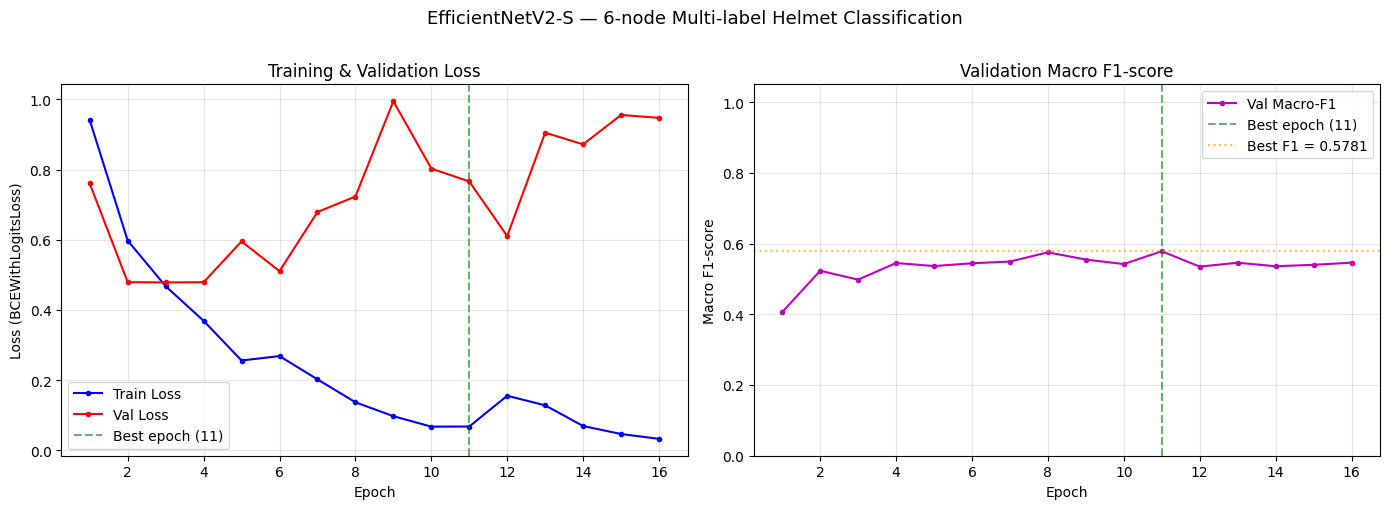

✓ Đồ thị đã lưu: /kaggle/working/training_curves.png


In [18]:
# ============================================================================
# VISUALIZE: Vẽ đồ thị Loss và Val Macro-F1 theo epoch
# ============================================================================

epochs_logged = [h['epoch']       for h in history]
train_losses  = [h['train_loss']  for h in history]
val_losses    = [h['val_loss']    for h in history]
val_f1s       = [h['val_macro_f1'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss Curves ---
axes[0].plot(epochs_logged, train_losses, 'b-o', markersize=3, label='Train Loss')
axes[0].plot(epochs_logged, val_losses,   'r-o', markersize=3, label='Val Loss')
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCEWithLogitsLoss)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Val Macro-F1 ---
axes[1].plot(epochs_logged, val_f1s, 'm-o', markersize=3, label='Val Macro-F1')
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[1].axhline(y=best_val_f1, color='orange', linestyle=':', alpha=0.7, label=f'Best F1 = {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1-score')
axes[1].set_title('Validation Macro F1-score')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.suptitle('EfficientNetV2-S — 6-node Multi-label Helmet Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Đồ thị đã lưu: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

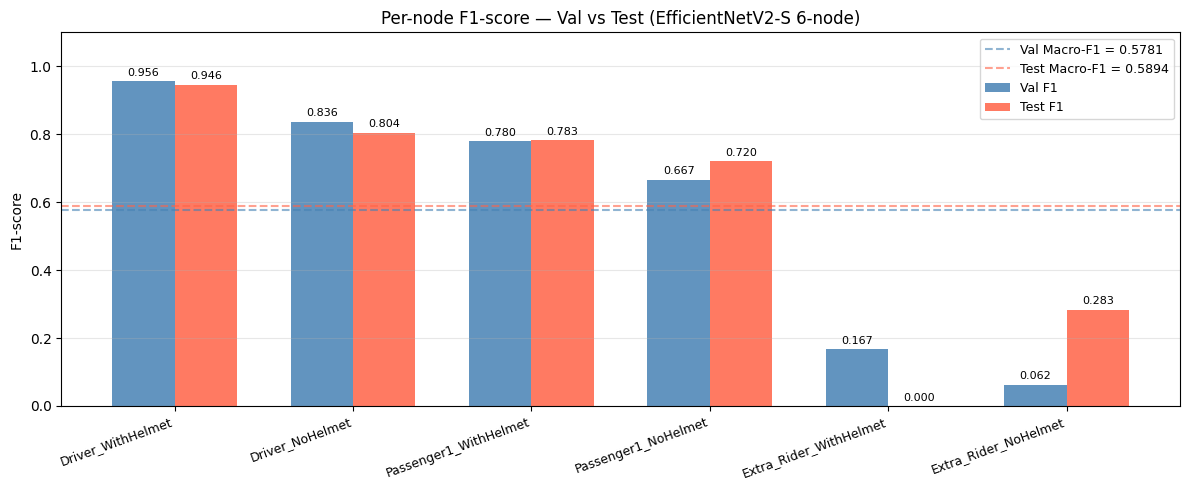

✓ Chart per-node F1 đã lưu: /kaggle/working/per_node_f1_chart.png


In [19]:
# ============================================================================
# VISUALIZE: Per-node F1 bar chart — so sánh Val vs Test
# ============================================================================

val_f1_per_node  = [n['f1'] for n in val_final['per_node']]
test_f1_per_node = [n['f1'] for n in test_final['per_node']]

x     = np.arange(NUM_NODES)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, val_f1_per_node,  width, label='Val F1',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, test_f1_per_node, width, label='Test F1', color='tomato',    alpha=0.85)

# Annotation: hiển thị giá trị trên mỗi bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

# Gạch ngang macro average
ax.axhline(y=val_final['macro_f1'],  color='steelblue', linestyle='--', alpha=0.6,
           label=f'Val Macro-F1 = {val_final["macro_f1"]:.4f}')
ax.axhline(y=test_final['macro_f1'], color='tomato',    linestyle='--', alpha=0.6,
           label=f'Test Macro-F1 = {test_final["macro_f1"]:.4f}')

ax.set_xticks(x)
ax.set_xticklabels(NODE_LABELS_FULL, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-node F1-score — Val vs Test (EfficientNetV2-S 6-node)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_node_f1_chart.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Chart per-node F1 đã lưu: {os.path.join(OUTPUT_DIR, 'per_node_f1_chart.png')}")

## Section 13b: Per-node Threshold Tuning

**Van de voi threshold=0.5 co dinh:**

- `pos_weight` trong BCEWithLogitsLoss chi anh huong **luc training**, khong anh huong nguong 0.5 luc inference
- Node co ty le positive rat thap (Extra_WithHelmet=1.5%, Extra_NoHelmet=3.9%) thuong co sigmoid output < 0.5 -> model khong bao gio predict 1 -> F1=0.000

**Giai phap:** Sweep threshold 0.05..0.95 tren **val set**, chon nguong maximize F1 cho tung node.

**Output:** `threshold_tuning.json` -> Step 5 se doc va dung de inference.

In [20]:
# ============================================================================
# PER-NODE THRESHOLD TUNING: Tim nguong toi uu cho tung node tren Val set
# ============================================================================
# Ly do can thiet:
#   - sigmoid(logits) >= 0.5: nguong mac dinh -- khong phu hop voi class mat can bang
#   - Node Extra_WithHelmet (1.5%) co sigmoid output thuong < 0.5 -> F1=0.000
#   - Giai phap: tim threshold toi uu per-node de maximize F1 tren val set
#   - Output luu vao threshold_tuning.json de Step 5 dung luc inference
# ============================================================================

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

print("=" * 80)
print("PER-NODE THRESHOLD TUNING TREN VAL SET")
print("=" * 80)

# --- Load best model ---
checkpoint = torch.load(BEST_WEIGHTS_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- Thu thap sigmoid probabilities tren val set ---
all_val_probs  = []
all_val_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_val_probs.append(probs)
        all_val_labels.append(labels.numpy())

all_val_probs  = np.vstack(all_val_probs)   # (N_val, 6)
all_val_labels = np.vstack(all_val_labels)  # (N_val, 6)

print(f"  Val set: {all_val_probs.shape[0]} samples, {all_val_probs.shape[1]} nodes")

# --- Sweep threshold cho tung node ---
THRESHOLD_CANDIDATES = np.arange(0.05, 0.96, 0.05).round(2)  # [0.05, 0.10, ..., 0.95]
optimal_thresholds   = []
threshold_results    = []

print()
print(f"  {'Node':<24} {'Thr@Opt':>8} {'F1@0.5':>8} {'F1@Opt':>8} {'Delta':>7} {'Ghi chu'}")
print("  " + "-" * 75)

for i in range(NUM_NODES):
    node_probs  = all_val_probs[:, i]
    node_labels = all_val_labels[:, i]

    # Baseline F1 tai threshold=0.5
    preds_05 = (node_probs >= 0.5).astype(int)
    f1_05    = f1_score(node_labels, preds_05, zero_division=0)

    # Sweep
    best_f1     = -1.0
    best_thresh = 0.5
    for thresh in THRESHOLD_CANDIDATES:
        preds = (node_probs >= thresh).astype(int)
        f1    = f1_score(node_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = float(thresh)

    optimal_thresholds.append(round(best_thresh, 2))
    delta = best_f1 - f1_05
    note  = "<-- dieu chinh" if abs(best_thresh - 0.5) > 0.049 else ""

    print(f"  {NODE_LABELS_FULL[i]:<24} {best_thresh:>8.2f} {f1_05:>8.4f} {best_f1:>8.4f} {delta:>+7.4f}  {note}")

    threshold_results.append({
        "node"          : NODE_NAMES[i],
        "full_name"     : NODE_LABELS_FULL[i],
        "threshold_opt" : round(best_thresh, 2),
        "f1_at_05"      : round(f1_05, 4),
        "f1_at_opt"     : round(best_f1, 4),
        "delta_f1"      : round(delta, 4),
    })

print()
print(f"  optimal_thresholds = {optimal_thresholds}")

# --- Danh gia lai tren TEST set voi optimal thresholds ---
print()
print("=" * 80)
print("DANH GIA TREN TAP TEST -- Fixed vs Per-node Threshold")
print("=" * 80)

all_test_probs  = []
all_test_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_test_probs.append(probs)
        all_test_labels.append(labels.numpy())

all_test_probs  = np.vstack(all_test_probs)
all_test_labels = np.vstack(all_test_labels)

preds_fixed = (all_test_probs >= 0.5).astype(int)
preds_opt   = np.column_stack([
    (all_test_probs[:, i] >= optimal_thresholds[i]).astype(int)
    for i in range(NUM_NODES)
])

print()
print(f"  {'Node':<24} {'F1@0.5':>8} {'F1@Opt':>8} {'Pre@Opt':>9} {'Rec@Opt':>9}")
print("  " + "-" * 63)

for i in range(NUM_NODES):
    f1_fx  = f1_score(all_test_labels[:, i], preds_fixed[:, i], zero_division=0)
    f1_op  = f1_score(all_test_labels[:, i], preds_opt[:, i],   zero_division=0)
    pre_op = precision_score(all_test_labels[:, i], preds_opt[:, i], zero_division=0)
    rec_op = recall_score(all_test_labels[:, i],    preds_opt[:, i], zero_division=0)
    print(f"  {NODE_LABELS_FULL[i]:<24} {f1_fx:>8.4f} {f1_op:>8.4f} {pre_op:>9.4f} {rec_op:>9.4f}")

macro_fixed = f1_score(all_test_labels, preds_fixed, average='macro', zero_division=0)
macro_opt   = f1_score(all_test_labels, preds_opt,   average='macro', zero_division=0)
print("  " + "-" * 63)
print(f"  {'Macro Average':<24} {macro_fixed:>8.4f} {macro_opt:>8.4f}")
print()
print(f"  Cai thien Macro F1: {macro_fixed:.4f} -> {macro_opt:.4f}  (Delta = {macro_opt - macro_fixed:+.4f})")

# --- Luu threshold_tuning.json ---
THRESHOLD_PATH = os.path.join(OUTPUT_DIR, 'threshold_tuning.json')
tuning_result = {
    "description"        : "Per-node threshold optimal tren Val set | Step 5 dung de inference",
    "tuning_split"       : "val",
    "threshold_fixed"    : 0.5,
    "optimal_thresholds" : {name: t for name, t in zip(NODE_NAMES, optimal_thresholds)},
    "per_node_detail"    : threshold_results,
    "test_macro_f1_fixed": round(macro_fixed, 4),
    "test_macro_f1_opt"  : round(macro_opt,   4),
}

with open(THRESHOLD_PATH, 'w', encoding='utf-8') as f:
    json.dump(tuning_result, f, indent=4, ensure_ascii=False)

print()
print(f"  Threshold tuning JSON da luu: {THRESHOLD_PATH}")
print()
print("  Step 5 se doc file nay va dung optimal_thresholds khi inference:")
for name, t in zip(NODE_NAMES, optimal_thresholds):
    print(f"    {name}: {t}")


# ============================================================================
# CONFLICT RESOLUTION: Xu ly ràng buộc loai tru lân nhau (Mutually Exclusive)
# ============================================================================
# 3 câp ràng buoc:
#   (Node0 D_H,  Node1 D_NH)   -> không the cùng = 1
#   (Node2 P1_H, Node3 P1_NH)  -> không the cùng = 1
#   (Node4 Ex_H, Node5 Ex_NH)  -> không the cùng = 1
#
# Chien luoc: Winner by probability (sigmoid cao hon thang)
# -> Khach quan nhat; Step 5 co the doi sang NoHelmet-wins neu can safety-first
# ============================================================================

MUTEX_PAIRS = [(0, 1), (2, 3), (4, 5)]  # (WithHelmet_idx, NoHelmet_idx)

def resolve_conflicts(pred_vec, prob_vec, strategy='prob'):
    """
    Xu ly conflict khi ca hai node trong cap mutually exclusive deu = 1.

    Args:
        pred_vec : list[int] -- vector 6-node binary sau threshold (0/1)
        prob_vec : list[float] -- sigmoid probability tuong ung
        strategy : 'prob'   -> winner by probability (mac dinh)
                   'nohelmet' -> NoHelmet luon thang (safety-first)
                   'unknown'  -> dat ca hai = 0 (khong ket luan)

    Returns:
        list[int]: vector 6-node da giai quyet conflict
    """
    vec = list(pred_vec)
    for idx_h, idx_nh in MUTEX_PAIRS:
        if vec[idx_h] == 1 and vec[idx_nh] == 1:
            # Conflict detected!
            if strategy == 'prob':
                # Winner: node co xac suat cao hon
                if prob_vec[idx_h] >= prob_vec[idx_nh]:
                    vec[idx_nh] = 0  # WithHelmet thang
                else:
                    vec[idx_h]  = 0  # NoHelmet thang
            elif strategy == 'nohelmet':
                vec[idx_h]  = 0      # NoHelmet luon thang (safety-first)
            elif strategy == 'unknown':
                vec[idx_h]  = 0
                vec[idx_nh] = 0      # Khong ket luan
    return vec


# --- Dem so luong conflict truoc va sau khi xu ly (tren test set) ---
conflict_counts_before = {f"{NODE_NAMES[h]}&{NODE_NAMES[nh]}": 0 for h, nh in MUTEX_PAIRS}
conflict_counts_after  = {f"{NODE_NAMES[h]}&{NODE_NAMES[nh]}": 0 for h, nh in MUTEX_PAIRS}

preds_resolved = np.copy(preds_opt)  # bat dau tu predictions da dung optimal threshold

for row_idx in range(len(all_test_probs)):
    # Kiem tra truoc khi giai quyet
    for h, nh in MUTEX_PAIRS:
        key = f"{NODE_NAMES[h]}&{NODE_NAMES[nh]}"
        if preds_opt[row_idx, h] == 1 and preds_opt[row_idx, nh] == 1:
            conflict_counts_before[key] += 1

    # Giai quyet conflict
    resolved = resolve_conflicts(
        preds_opt[row_idx].tolist(),
        all_test_probs[row_idx].tolist(),
        strategy='prob'
    )
    preds_resolved[row_idx] = resolved

    # Kiem tra sau khi giai quyet
    for h, nh in MUTEX_PAIRS:
        key = f"{NODE_NAMES[h]}&{NODE_NAMES[nh]}"
        if resolved[h] == 1 and resolved[nh] == 1:
            conflict_counts_after[key] += 1

print()
print("=" * 60)
print("CONFLICT RESOLUTION RESULTS (Test set)")
print("=" * 60)
print(f"  {'Cap ràng buoc':<25} {'Conflict truoc':>14} {'Conflict sau':>13}")
print("  " + "-" * 55)
total_before = 0
total_after  = 0
for key in conflict_counts_before:
    b = conflict_counts_before[key]
    a = conflict_counts_after[key]
    total_before += b
    total_after  += a
    print(f"  {key:<25} {b:>14} {a:>13}")
print("  " + "-" * 55)
print(f"  {'TOTAL':<25} {total_before:>14} {total_after:>13}")

# Macro F1 sau khi resolve
macro_resolved = f1_score(all_test_labels, preds_resolved, average='macro', zero_division=0)
print()
print(f"  Macro F1 @0.5    : {macro_fixed:.4f}")
print(f"  Macro F1 @Opt    : {macro_opt:.4f}")
print(f"  Macro F1 @Opt+CR : {macro_resolved:.4f}  (sau conflict resolution)")

# Luu them thong tin vao threshold_tuning.json
with open(THRESHOLD_PATH, 'r', encoding='utf-8') as f:
    tuning_data = json.load(f)

tuning_data["conflict_resolution"] = {
    "strategy"             : "prob",
    "mutex_pairs"          : [[NODE_NAMES[h], NODE_NAMES[nh]] for h, nh in MUTEX_PAIRS],
    "conflicts_on_test"    : conflict_counts_before,
    "test_macro_f1_opt_cr" : round(macro_resolved, 4),
    "note": "Step 5 goi resolve_conflicts(pred_vec, prob_vec, strategy='prob') sau khi ap dung optimal_thresholds"
}

with open(THRESHOLD_PATH, 'w', encoding='utf-8') as f:
    json.dump(tuning_data, f, indent=4, ensure_ascii=False)

print()
print(f"  Conflict resolution info da luu vao: {THRESHOLD_PATH}")
print()
print("  Step 5 inference flow:")
print("    logits -> sigmoid -> probs -> preds(optimal_threshold) -> resolve_conflicts() -> CHUE voting")


PER-NODE THRESHOLD TUNING TREN VAL SET
  Val set: 1043 samples, 6 nodes

  Node                      Thr@Opt   F1@0.5   F1@Opt   Delta Ghi chu
  ---------------------------------------------------------------------------
  Driver_WithHelmet            0.30   0.9562   0.9591 +0.0029  <-- dieu chinh
  Driver_NoHelmet              0.65   0.8364   0.8380 +0.0016  <-- dieu chinh
  Passenger1_WithHelmet        0.35   0.7802   0.7859 +0.0057  <-- dieu chinh
  Passenger1_NoHelmet          0.90   0.6667   0.7344 +0.0677  <-- dieu chinh
  Extra_Rider_WithHelmet       0.65   0.1667   0.2000 +0.0333  <-- dieu chinh
  Extra_Rider_NoHelmet         0.25   0.0625   0.1905 +0.1280  <-- dieu chinh

  optimal_thresholds = [0.3, 0.65, 0.35, 0.9, 0.65, 0.25]

DANH GIA TREN TAP TEST -- Fixed vs Per-node Threshold

  Node                       F1@0.5   F1@Opt   Pre@Opt   Rec@Opt
  ---------------------------------------------------------------
  Driver_WithHelmet          0.9461   0.9490    0.9555    0.9427


## Section 13c: Visual Prediction Demo tren Tap Test

Chon ngau nhien anh tu tap test, chay inference voi full pipeline:

`sigmoid -> optimal threshold -> conflict resolution -> hien thi ket qua`

Moi anh hien thi:
- **GT**: Ground truth tu multilabel_dataset.csv
- **Pred**: Predicted labels sau full pipeline
- **Prob**: Sigmoid probability cho tung node
- Vien **xanh la** = predict dung / **do** = predict sai

Tap test: 1687 samples


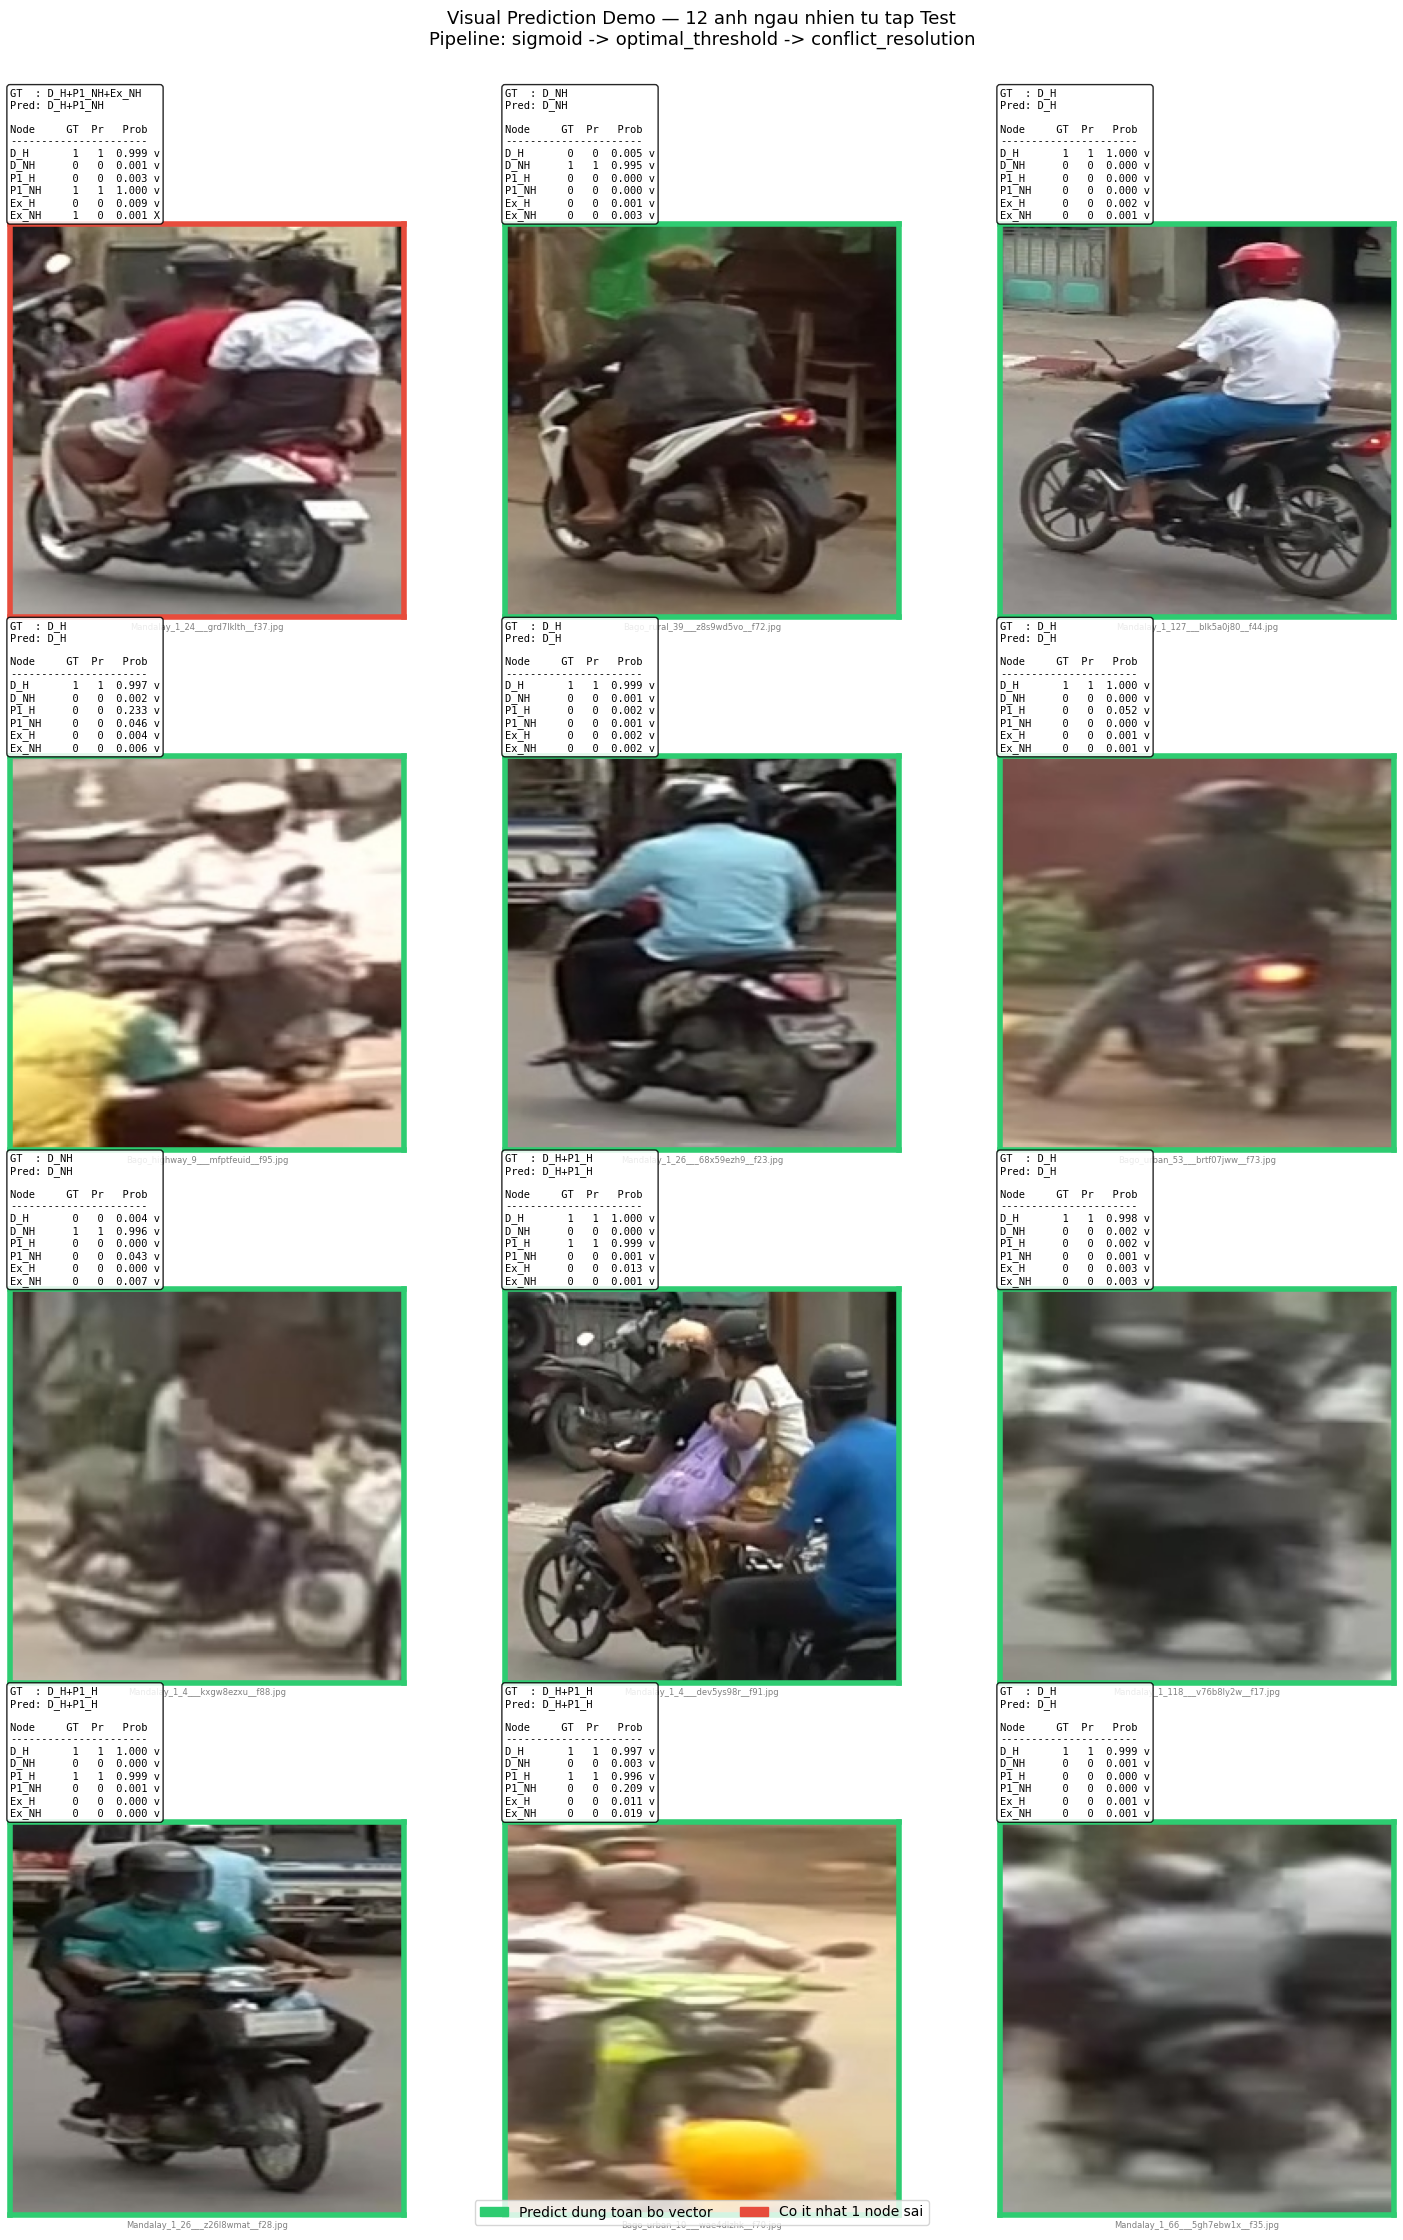

Demo da luu: /kaggle/working/prediction_demo.png

Tren 12 anh demo:
  Predict dung toan bo vector: 11/12 (92%)


In [31]:
# ============================================================================
# VISUAL PREDICTION DEMO: Predict thu tren anh test voi full pipeline
# ============================================================================
# Pipeline:
#   image -> model -> sigmoid(logits) -> optimal_threshold -> resolve_conflicts
#            -> hien thi: GT label | Predicted label | Probability per node
# ============================================================================

import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# --- Dam bao model o eval mode ---
checkpoint = torch.load(BEST_WEIGHTS_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# --- Doc danh sach anh test tu CSV ---
test_df = pd.read_csv(CSV_PATH)
test_df = test_df[test_df['split'] == 'test'].reset_index(drop=True)
print(f"Tap test: {len(test_df)} samples")

# --- Chon ngau nhien N_DEMO anh ---
N_DEMO = 12   # So luong anh muon hien thi (chia thanh grid 3 cot)
N_COLS = 3
N_ROWS = (N_DEMO + N_COLS - 1) // N_COLS

# random.seed(42)  # Loại bỏ seed cố định để được ngẫu nhiên mỗi lần chạy
sample_indices = random.sample(range(len(test_df)), min(N_DEMO, len(test_df)))

# --- Helper: format label vector thanh chuoi ngan ---
SHORT_NAMES = ['D_H', 'D_NH', 'P1_H', 'P1_NH', 'Ex_H', 'Ex_NH']

def vec_to_str(vec):
    active = [SHORT_NAMES[i] for i, v in enumerate(vec) if v == 1]
    return '+'.join(active) if active else 'NONE'

# --- Inference function voi full pipeline ---
def predict_single(img_path, optimal_thresholds_list, strategy='prob'):
    """
    Doc anh, chay model, ap dung threshold + conflict resolution.
    Returns: (pred_vec, prob_vec)
    """
    img = Image.open(img_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.sigmoid(logits).squeeze().cpu().numpy()

    # Ap dung optimal threshold per-node
    pred_vec = [int(probs[i] >= optimal_thresholds_list[i]) for i in range(NUM_NODES)]

    # Conflict resolution
    pred_vec = resolve_conflicts(pred_vec, probs.tolist(), strategy=strategy)

    return pred_vec, probs.tolist()

# --- Ve ---
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 5, N_ROWS * 5.5))
axes = axes.flatten() if N_DEMO > 1 else [axes]

for plot_idx, sample_idx in enumerate(sample_indices):
    row = test_df.iloc[sample_idx]
    img_path   = os.path.join(IMG_DIR, row['file_name'])
    gt_vec     = [int(row[col]) for col in NODE_NAMES]

    # Predict
    pred_vec, prob_vec = predict_single(img_path, optimal_thresholds)

    # Kiem tra dung/sai (toan bo vector)
    is_fully_correct = (gt_vec == pred_vec)
    border_color     = '#2ecc71' if is_fully_correct else '#e74c3c'

    # Hien thi anh
    ax = axes[plot_idx]
    try:
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#cccccc')

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    # Tao bang text hien thi per-node
    lines = []
    lines.append(f"GT  : {vec_to_str(gt_vec)}")
    lines.append(f"Pred: {vec_to_str(pred_vec)}")
    lines.append("")
    lines.append(f"{'Node':<7} {'GT':>3} {'Pr':>3} {'Prob':>6}")
    lines.append("-" * 22)
    for i in range(NUM_NODES):
        correct_mark = "v" if gt_vec[i] == pred_vec[i] else "X"
        lines.append(
            f"{SHORT_NAMES[i]:<7} {gt_vec[i]:>3} {pred_vec[i]:>3} {prob_vec[i]:>6.3f} {correct_mark}"
        )

    title_text = "\n".join(lines)
    ax.set_title(title_text, fontsize=7.5, family='monospace',
                 loc='left', pad=4,
                 color='black',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    # Tieu de nho hien thi ten file
    ax.set_xlabel(row['file_name'][:40], fontsize=6, color='gray')

# An cac subplot thua
for j in range(plot_idx + 1, len(axes)):
    axes[j].axis('off')

# Legend
patch_ok  = mpatches.Patch(color='#2ecc71', label='Predict dung toan bo vector')
patch_err = mpatches.Patch(color='#e74c3c', label='Co it nhat 1 node sai')
fig.legend(handles=[patch_ok, patch_err], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.0))

fig.suptitle(
    f'Visual Prediction Demo — {N_DEMO} anh ngau nhien tu tap Test\n'
    f'Pipeline: sigmoid -> optimal_threshold -> conflict_resolution',
    fontsize=13, y=1.01
)
plt.tight_layout()

demo_path = os.path.join(OUTPUT_DIR, 'prediction_demo.png')
plt.savefig(demo_path, dpi=110, bbox_inches='tight')
plt.show()
print(f"Demo da luu: {demo_path}")

# --- Thong ke nhanh ---
n_correct_full = 0
n_conflict_resolved = 0
for idx in sample_indices:
    row = test_df.iloc[idx]
    img_path = os.path.join(IMG_DIR, row['file_name'])
    gt_vec   = [int(row[col]) for col in NODE_NAMES]
    pred_vec, prob_vec = predict_single(img_path, optimal_thresholds)
    if gt_vec == pred_vec: n_correct_full += 1

print(f"\nTren {N_DEMO} anh demo:")
print(f"  Predict dung toan bo vector: {n_correct_full}/{N_DEMO} ({100*n_correct_full/N_DEMO:.0f}%)")


## Section 13: Export Weights + training_history.json — Kết thúc Phần 4

In [21]:
# ============================================================================
# EXPORT: Lưu training_history.json và summary bước 4
# ============================================================================

# --- Ghi lại training history (loss, F1 mỗi epoch) ---
history_path = os.path.join(OUTPUT_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4, ensure_ascii=False)
print(f"✓ Training history đã lưu: {history_path}")

# --- Summary JSON bước 4 để Step 5 verify ---
step4_summary = {
    "step"            : 4,
    "description"     : "EfficientNetV2-S 6-node Multi-label Classifier",
    "model"           : "efficientnet_v2_s",
    "best_epoch"      : int(best_epoch),
    "epochs_trained"  : len(history),
    "hyperparameters" : {
        "batch_size"  : BATCH_SIZE,
        "lr"          : LR,
        "weight_decay": WEIGHT_DECAY,
        "optimizer"   : "AdamW",
        "scheduler"   : "CosineAnnealingLR",
        "pos_weights" : POS_WEIGHTS,
        "threshold"   : THRESHOLD,
    },
    "val_metrics"     : {
        "macro_f1" : val_final['macro_f1'],
        "loss"     : val_final['loss'],
        "per_node" : val_final['per_node'],
    },
    "test_metrics"    : {
        "macro_f1" : test_final['macro_f1'],
        "loss"     : test_final['loss'],
        "per_node" : test_final['per_node'],
    },
    "paths": {
        "best_weights"    : BEST_WEIGHTS_PATH,
        "training_history": history_path,
        "training_curves" : os.path.join(OUTPUT_DIR, 'training_curves.png'),
        "per_node_chart"  : os.path.join(OUTPUT_DIR, 'per_node_f1_chart.png'),
    },
    "node_names"      : NODE_NAMES,
    "node_full_names" : NODE_LABELS_FULL,
    "notes": (
        "Node Extra_Rider (4 & 5) dự kiến có F1 thấp hơn do giới hạn dữ liệu OSF Lite "
        "(P3_WithHelmet=0 mẫu). Đây là hạn chế dữ liệu, không phải lỗi kiến trúc."
    )
}

step4_summary_path = os.path.join(OUTPUT_DIR, 'step4_train_efficientnet_summary.json')
with open(step4_summary_path, 'w') as f:
    json.dump(step4_summary, f, indent=4, ensure_ascii=False)

# --- In tổng kết ---
print()
print("=" * 80)
print("✓ STEP 4 HOÀN TẤT — Tổng kết")
print("=" * 80)
print(f"  Model          : EfficientNetV2-S (pretrained ImageNet)")
print(f"  Best weights   : {BEST_WEIGHTS_PATH}")
print(f"  Best epoch     : {best_epoch}")
print()
print("  Validation metrics:")
print(f"    Macro-F1 : {val_final['macro_f1']:.4f}")
print(f"    Loss     : {val_final['loss']:.6f}")
for n in val_final['per_node']:
    print(f"    {n['node']:<10}: F1={n['f1']:.4f}  Pre={n['precision']:.4f}  Rec={n['recall']:.4f}")
print()
print("  Test metrics:")
print(f"    Macro-F1 : {test_final['macro_f1']:.4f}")
print(f"    Loss     : {test_final['loss']:.6f}")
for n in test_final['per_node']:
    print(f"    {n['node']:<10}: F1={n['f1']:.4f}  Pre={n['precision']:.4f}  Rec={n['recall']:.4f}")
print()
print(f"  Summary JSON   : {step4_summary_path}")
print()
print("  Bước tiếp theo:")
print("    1. Dùng efficientnet_best.pth trong Step 5 (pipeline end-to-end + CHUE Voting)")
print("    2. Step 5 sẽ kết hợp output của Step 3 (BoT-SORT crops) với model này")
print("    3. Sau Step 5, tiến hành Step 6 (Evaluation — so sánh với GT annotation)")

✓ Training history đã lưu: /kaggle/working/training_history.json

✓ STEP 4 HOÀN TẤT — Tổng kết
  Model          : EfficientNetV2-S (pretrained ImageNet)
  Best weights   : /kaggle/working/efficientnet_best.pth
  Best epoch     : 11

  Validation metrics:
    Macro-F1 : 0.5781
    Loss     : 0.766262
    D_H       : F1=0.9562  Pre=0.9574  Rec=0.9550
    D_NH      : F1=0.8364  Pre=0.8364  Rec=0.8364
    P1_H      : F1=0.7802  Pre=0.7510  Rec=0.8117
    P1_NH     : F1=0.6667  Pre=0.6049  Rec=0.7424
    Extra_H   : F1=0.1667  Pre=0.1429  Rec=0.2000
    Extra_NH  : F1=0.0625  Pre=0.0588  Rec=0.0667

  Test metrics:
    Macro-F1 : 0.5894
    Loss     : 1.306423
    D_H       : F1=0.9461  Pre=0.9644  Rec=0.9285
    D_NH      : F1=0.8043  Pre=0.7551  Rec=0.8605
    P1_H      : F1=0.7826  Pre=0.7500  Rec=0.8182
    P1_NH     : F1=0.7203  Pre=0.6773  Rec=0.7692
    Extra_H   : F1=0.0000  Pre=0.0000  Rec=0.0000
    Extra_NH  : F1=0.2832  Pre=0.5000  Rec=0.1975

  Summary JSON   : /kaggle/working/